Это обзорный ноутбук, служит для  того, чтобы было легче ознакомиться с данными, что мы имеем

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_categories = pd.read_csv('D:\ML_innovise\item_categories.csv')
df_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [3]:
df_items = pd.read_csv('D:\ML_innovise\items.csv')
df_items.head()


,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [4]:
df_sales_train = pd.read_csv('D:\ML_innovise\sales_train.csv')
df_sales_train.head()


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [5]:
df_submission = pd.read_csv('D:\ML_innovise\sample_submission.csv')
df_submission.head()


,ID,item_cnt_month
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5


In [6]:
df_shops = pd.read_csv('D:\ML_innovise\shops.csv')
df_shops.head()


,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [7]:
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')
df_testt.head()


,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


363 товара вообще никогда не продавали за всю историю продаж

In [8]:
df= df_items.merge(
    df_categories,
    on='item_category_id',
    how='outer',     
    validate='many_to_one'
)
df.head()

,item_name,item_id,item_category_id,item_category_name
0,PC: Гарнитура HyperX Cloud Core игровая стерео...,5441,0,PC - Гарнитуры/Наушники
1,Наушники PHILIPS SBC HC8680,16255,0,PC - Гарнитуры/Наушники
2,Наушники RITMIX RH-120,16256,0,PC - Гарнитуры/Наушники
3,Наушники RITMIX RH-124 Black,16257,0,PC - Гарнитуры/Наушники
4,PS2: Карта памяти 8 Мб черная (Memory Card 8Mb...,5606,1,Аксессуары - PS2


In [9]:
df.isnull().sum()

item_name             0
item_id               0
item_category_id      0
item_category_name    0
dtype: int64

In [10]:
df_1 = df_sales_train.merge(
    df,
    on='item_id',
    how='left',     
    validate='many_to_one'
)
df_1.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства


In [11]:
df_1.isnull().sum()

date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
item_name             0
item_category_id      0
item_category_name    0
dtype: int64

In [12]:
df_1 = df_1.merge(
    df_shops,
    on='shop_id',
    how='left',     
    validate='many_to_one'
)
df_1.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир"""
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум"""


In [13]:
# датасет, который содержит вообще всю информацию про продаваемость товаров за весь период 
df_1.isnull().sum()

date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
dtype: int64

In [14]:
df_2 = df_testt.merge(
    df,
    on='item_id',
    how='left',     
    validate='many_to_one'
)
df_2.head()

,ID,shop_id,item_id,item_name,item_category_id,item_category_name
0,0,5,5037,"NHL 15 [PS3, русские субтитры]",19,Игры - PS3
1,1,5,5320,ONE DIRECTION Made In The A.M.,55,Музыка - CD локального производства
2,2,5,5233,"Need for Speed Rivals (Essentials) [PS3, русск...",19,Игры - PS3
3,3,5,5232,"Need for Speed Rivals (Classics) [Xbox 360, ру...",23,Игры - XBOX 360
4,4,5,5268,"Need for Speed [PS4, русская версия]",20,Игры - PS4


In [15]:
df_2.isnull().sum()

ID                    0
shop_id               0
item_id               0
item_name             0
item_category_id      0
item_category_name    0
dtype: int64

In [16]:
df_2 = df_2.merge(
    df_shops,
    on='shop_id',
    how='left',     
    validate='many_to_one'
)
df_2.head()

,ID,shop_id,item_id,item_name,item_category_id,item_category_name,shop_name
0,0,5,5037,"NHL 15 [PS3, русские субтитры]",19,Игры - PS3,"Вологда ТРЦ ""Мармелад"""
1,1,5,5320,ONE DIRECTION Made In The A.M.,55,Музыка - CD локального производства,"Вологда ТРЦ ""Мармелад"""
2,2,5,5233,"Need for Speed Rivals (Essentials) [PS3, русск...",19,Игры - PS3,"Вологда ТРЦ ""Мармелад"""
3,3,5,5232,"Need for Speed Rivals (Classics) [Xbox 360, ру...",23,Игры - XBOX 360,"Вологда ТРЦ ""Мармелад"""
4,4,5,5268,"Need for Speed [PS4, русская версия]",20,Игры - PS4,"Вологда ТРЦ ""Мармелад"""


In [17]:
df_2.isnull().sum()

ID                    0
shop_id               0
item_id               0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
dtype: int64

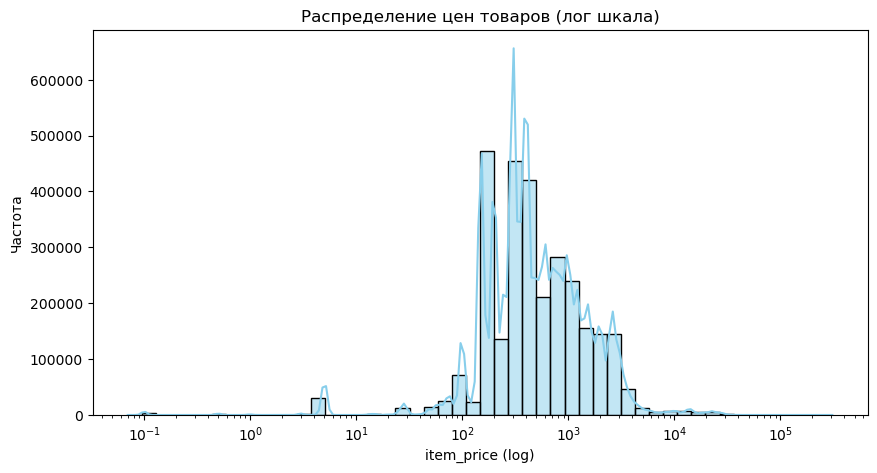

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df_1['item_price'],
             bins=50,
             kde=True,
             color='skyblue',
             edgecolor='black',
             log_scale=(True, False)) 
plt.title('Распределение цен товаров (лог шкала)')
plt.xlabel('item_price (log)')
plt.ylabel('Частота')
plt.show()


<Axes: ylabel='item_price'>

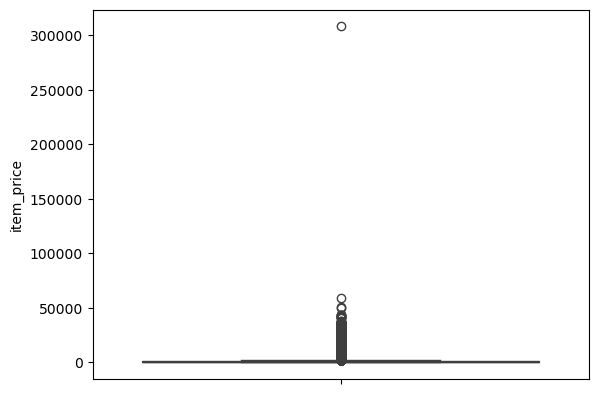

In [19]:
sns.boxplot(df_1['item_price'])


In [20]:
# сначала разберемся. что же за выбросы в цене товара
rich_items = df_1[df_1['item_price'] > 100_000]
(len(rich_items))
rich_items.head(5)


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
1163158,13.12.2013,11,12,6066,307980.0,1.0,Radmin 3 - 522 лиц.,75,Программы - Для дома и офиса,Интернет-магазин ЧС


In [21]:
# поскольку ошибка в этом товаре произошла один раз, товар вообще продавался один раз всю историю и предсказывать его продаваемость не будем - удаляем 
df_1 = df_1[df_1['item_id'] != 6066]


<Axes: ylabel='item_price'>

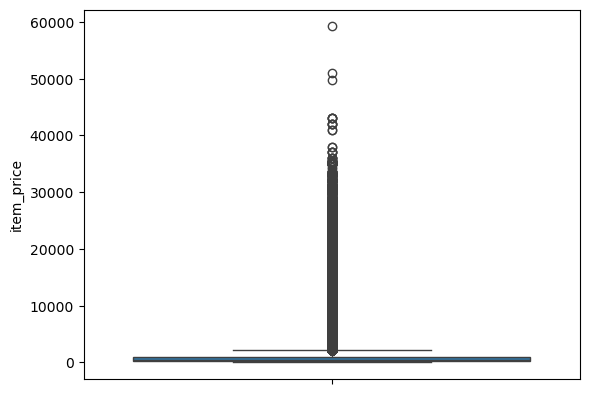

In [22]:
sns.boxplot(df_1['item_price'])

In [23]:
selected = df_1[df_1['item_price']<0]
selected

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
484683,15.05.2013,4,32,2973,-1.0,1.0,"DmC Devil May Cry [PS3, русские субтитры]",19,Игры - PS3,"Москва ТЦ ""Серебряный Дом"""


In [24]:
df_1 = df_1[df_1['item_price']>0]


In [25]:
selected = df_1[df_1['item_price']<0]
selected

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name


Все, от выбросов в плане цен мы избавились, теперь разбираемся с выбросами в плане продаваемости

In [26]:
df_1['item_cnt_day'] = df_1['item_cnt_day'].astype(int) # заменим на целое количество проданных товаров за день 


Text(0.5, 1.0, 'Сумма продаж по месяцам')

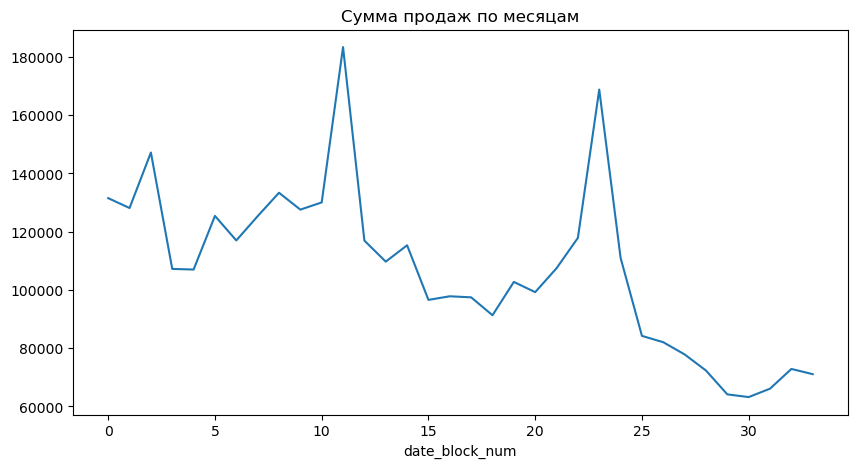

In [27]:
df_1.groupby('date_block_num')['item_cnt_day'].sum().plot(figsize=(10,5))
plt.title('Сумма продаж по месяцам')


По графику видно, что нет разрывов и есть данные о каждом месяце за данный промежуток времени, есть скачки, но они не похожи на аномальные, видна даже нейкая периодичность (сезонность)

<Axes: ylabel='item_cnt_day'>

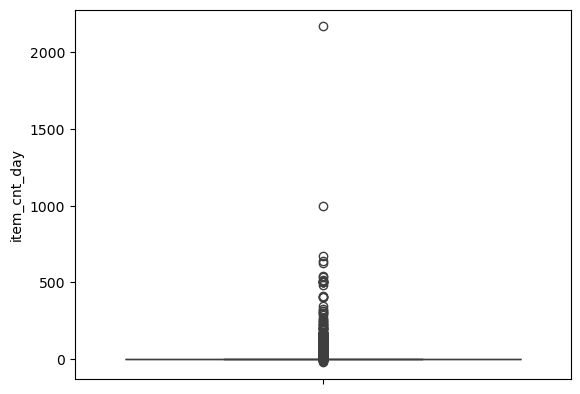

In [28]:
sns.boxplot(df_1['item_cnt_day'])

In [29]:
selected = df_1[df_1['item_cnt_day'] > 900]
selected


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2326930,15.01.2015,24,12,20949,4.000000,1000,Фирменный пакет майка 1С Интерес белый (34*42)...,71,"Подарки - Сумки, Альбомы, Коврики д/мыши",Интернет-магазин ЧС
2909818,28.10.2015,33,12,11373,0.908714,2169,Доставка до пункта выдачи (Boxberry),9,Доставка товара,Интернет-магазин ЧС


In [30]:
df_1['item_cnt_day'].value_counts()

item_cnt_day
1       2629370
2        194201
3         47350
4         19685
5         10474
         ...   
669           1
157           1
504           1
161           1
2169          1
Name: count, Length: 198, dtype: int64

In [31]:
df_1 = df_1[df_1['item_cnt_day'] <= 900]

<Axes: ylabel='item_cnt_day'>

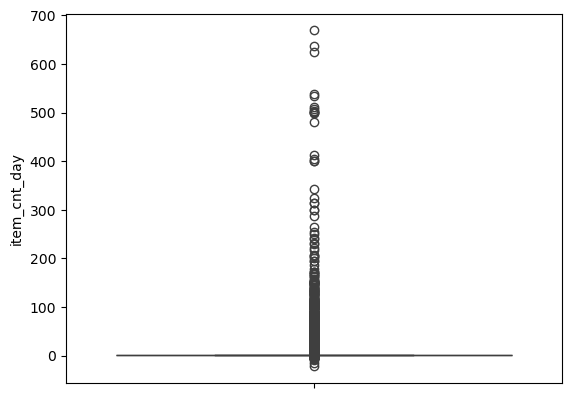

In [32]:
sns.boxplot(df_1['item_cnt_day'])


In [33]:
df_month = (
    df_1
    .groupby(
        ['shop_id', 'item_id', 'date_block_num','item_category_id'],
        as_index=False
    )
    .agg({
        'item_price':  'first',    
        'item_cnt_day':'sum'      
    })
)

df_month = df_month.rename(
    columns={'item_cnt_day': 'item_cnt_month'}
)

df_month = df_month[
    ['item_id','shop_id','item_price','date_block_num','item_cnt_month','item_category_id']
]

df_month.head()


,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id
0,30,0,265.0,1,31,40
1,31,0,434.0,1,11,37
2,32,0,221.0,0,6,40
3,32,0,221.0,1,10,40
4,33,0,347.0,0,3,37


<Axes: ylabel='item_cnt_month'>

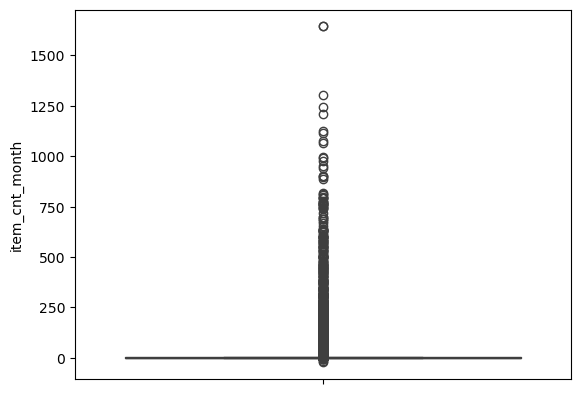

In [34]:
sns.boxplot(df_month['item_cnt_month'])

In [35]:
selected = df_month[df_month['item_cnt_month']>1500]
selected

,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id
197728,9248,12,1692.526158,32,1644,80
1439162,9249,55,1500.000000,32,1644,8


In [36]:
selected = df_month[df_month['item_cnt_month']<0]
selected

,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id
9329,1915,2,249.0,9,-1,30
10391,2854,2,199.0,15,-1,30
10891,3158,2,1290.0,1,-1,75
13482,4907,2,1499.0,12,-1,23
15072,6457,2,599.0,7,-1,30
...,...,...,...,...,...,...
1594220,7299,59,399.0,16,-1,55
1600162,13501,59,5790.0,0,-1,13
1601784,14931,59,699.0,0,-2,69
1604883,17346,59,169.0,18,-1,40


In [37]:
df_11 = df_1[(df_1['item_id']==9248) & (df_1['shop_id']==12) & (df_1['date_block_num']==32)]
df_11.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2864235,30.09.2015,32,12,9248,1692.526158,669,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864260,29.09.2015,32,12,9248,1500.000000,504,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864262,28.09.2015,32,12,9248,1500.000000,139,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864263,26.09.2015,32,12,9248,1500.000000,57,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС
2864265,01.09.2015,32,12,9248,1500.000000,3,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,Служебные - Билеты,Интернет-магазин ЧС


In [38]:
df_11 = df_1[(df_1['item_id']==9249) & (df_1['shop_id']==55) & (df_1['date_block_num']==32)]
df_11.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2851022,01.09.2015,32,55,9249,1500.0,3,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851023,02.09.2015,32,55,9249,1500.0,3,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851024,03.09.2015,32,55,9249,1500.0,1,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851025,04.09.2015,32,55,9249,1500.0,1,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн
2851026,06.09.2015,32,55,9249,1500.0,5,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,Билеты (Цифра),Цифровой склад 1С-Онлайн


In [39]:
df_month=df_month[df_month['item_cnt_month']<1500]

<Axes: ylabel='item_cnt_month'>

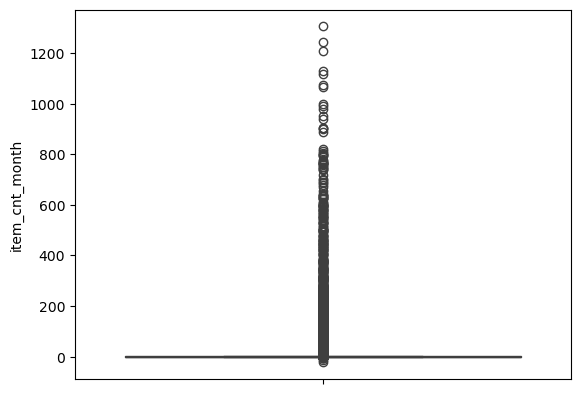

In [40]:
sns.boxplot(df_month['item_cnt_month'])

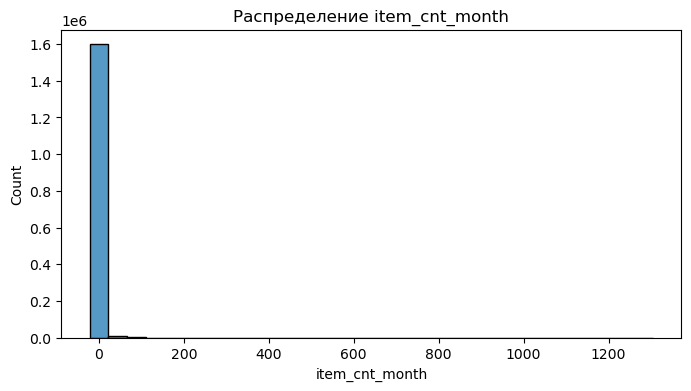

In [41]:

plt.figure(figsize=(8,4))
sns.histplot(data=df_month, x='item_cnt_month', bins=30, kde=False)
plt.title('Распределение item_cnt_month')
plt.show()


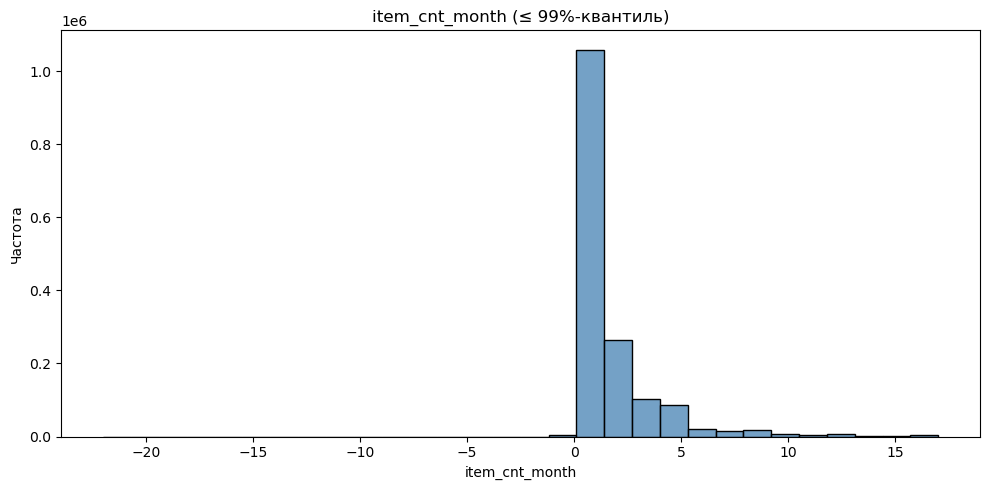

In [42]:

q99 = df_month['item_cnt_month'].quantile(0.99)
df_cut = df_month[df_month['item_cnt_month'] <= q99]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_cut,
    x='item_cnt_month',
    bins=30,
    kde=False,
    color='steelblue'
)
plt.title(f'item_cnt_month (≤ 99%-квантиль)')
plt.xlabel('item_cnt_month')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()


In [43]:
df_month['item_cnt_month'] = df_month['item_cnt_month'].clip(lower=0, upper=20)

Теперь прошерстим магазины

In [44]:
import re
def clean_name(s):
    s = s.lower().strip()
    s = re.sub(r"[^а-яa-z0-9\s]", "", s)
    return s


In [45]:
# from scripts.src1 import clean_name

df_shops['shop_clean'] = df_shops['shop_name'].apply(clean_name)



In [46]:
df_shops.head()

,shop_name,shop_id,shop_clean
0,"!Якутск Орджоникидзе, 56 фран",0,якутск орджоникидзе 56 фран
1,"!Якутск ТЦ ""Центральный"" фран",1,якутск тц центральный фран
2,"Адыгея ТЦ ""Мега""",2,адыгея тц мега
3,"Балашиха ТРК ""Октябрь-Киномир""",3,балашиха трк октябрькиномир
4,"Волжский ТЦ ""Волга Молл""",4,волжский тц волга молл


In [47]:
sorted_shops = df_shops['shop_clean'].sort_values()
print(sorted_shops.to_list())

['адыгея тц мега', 'балашиха трк октябрькиномир', 'волжский тц волга молл', 'вологда трц мармелад', 'воронеж плехановская 13', 'воронеж трц максимир', 'воронеж трц ситипарк град', 'выездная торговля', 'жуковский ул чкалова 39м', 'жуковский ул чкалова 39м', 'интернетмагазин чс', 'казань тц бехетле', 'казань тц паркхаус ii', 'калуга трц xxi век', 'коломна тц рио', 'красноярск тц взлетка плаза', 'красноярск тц июнь', 'курск тц пушкинский', 'москва магазин с21', 'москва мтрц афи молл', 'москва распродажа', 'москва тк буденовский пава2', 'москва тк буденовский павк7', 'москва трк атриум', 'москва тц ареал беляево', 'москва тц мега белая дача ii', 'москва тц мега теплый стан ii', 'москва тц новый век новокосино', 'москва тц перловский', 'москва тц семеновский', 'москва тц серебряный дом', 'мытищи трк xl3', 'нновгород трц рио', 'нновгород трц фантастика', 'новосибирск трц галерея новосибирск', 'новосибирск тц мега', 'омск тц мега', 'ростовнадону трк мегацентр горизонт', 'ростовнадону трк мега

Сейчас я буду чекать, какие магазины вызывают сомнение, что они различны :
"РостовНаДону ТРК ""Мегацентр Горизонт""",39
"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной",40

Жуковский ул. Чкалова 39м?,10
Жуковский ул. Чкалова 39м²,11
 С моей моральной точки зрения - это будут одинаковые магазины, нам нужно будет доказать по их продажам, что это так 

'ростовнадону трк мегацентр горизонт', 'ростовнадону трк мегацентр горизонт островной', 'ростовнадону тц мега'
'якутск орджоникидзе 56', 'якутск орджоникидзе 56 фран'
'якутск тц центральный', 'якутск тц центральный фран'

In [48]:
df_11 = df_1[df_1['shop_id']==39]
df_11.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
1530388,02.03.2014,14,39,1324,499.0,1,ARMSTRONG LOUIS Essential Collection 3CD,55,Музыка - CD локального производства,"РостовНаДону ТРК ""Мегацентр Горизонт"""
1530389,23.03.2014,14,39,1305,299.0,1,ARMIN VAN BUUREN A State Of Trance 2013 2CD ...,55,Музыка - CD локального производства,"РостовНаДону ТРК ""Мегацентр Горизонт"""
1530390,30.03.2014,14,39,1303,299.0,1,ARMIN VAN BUUREN A State Of Trance Year Mix ...,55,Музыка - CD локального производства,"РостовНаДону ТРК ""Мегацентр Горизонт"""
1530391,11.03.2014,14,39,1202,1599.0,1,AC/DC Back In Black 180 GRAMM Limited Editi...,58,Музыка - Винил,"РостовНаДону ТРК ""Мегацентр Горизонт"""
1530392,06.03.2014,14,39,1201,299.0,1,AC/DC Back In Black,55,Музыка - CD локального производства,"РостовНаДону ТРК ""Мегацентр Горизонт"""


In [49]:
df_22= df_1[df_1['shop_id']==40]
df_22.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
1533149,12.03.2014,14,40,10376,399.0,1,ГЕОГРАФ ГЛОБУС ПРОПИЛ,40,Кино - DVD,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"
1533150,27.03.2014,14,40,10098,749.0,1,ВСЕЛЕННАЯ: КАТАСТРОФЫ В ДАЛЕКИХ МИРАХ (3D BD),38,Кино - Blu-Ray 3D,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"
1533151,27.03.2014,14,40,9863,699.0,1,ВИЙ (3D BD+BD),38,Кино - Blu-Ray 3D,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"
1533152,23.03.2014,14,40,9862,399.0,1,ВИЙ,40,Кино - DVD,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"
1533153,10.03.2014,14,40,9862,399.0,2,ВИЙ,40,Кино - DVD,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"


In [50]:
df_33= df_1[df_1['shop_id']==41]
df_33.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
101805,05.01.2013,0,41,2956,598.5,1,Disney/Pixar. История игрушек. Большой побег (...,21,Игры - PSP,"РостовНаДону ТЦ ""Мега"""
101806,04.01.2013,0,41,2956,599.0,1,Disney/Pixar. История игрушек. Большой побег (...,21,Игры - PSP,"РостовНаДону ТЦ ""Мега"""
101807,05.01.2013,0,41,2953,299.5,1,"Disney/Pixar. Вверх! (Essentials) [PSP, русска...",21,Игры - PSP,"РостовНаДону ТЦ ""Мега"""
101808,03.01.2013,0,41,2953,299.5,1,"Disney/Pixar. Вверх! (Essentials) [PSP, русска...",21,Игры - PSP,"РостовНаДону ТЦ ""Мега"""
101809,24.01.2013,0,41,2946,599.0,1,"Disney. ТРОН: Эволюция (Essentials) [PSP, англ...",21,Игры - PSP,"РостовНаДону ТЦ ""Мега"""


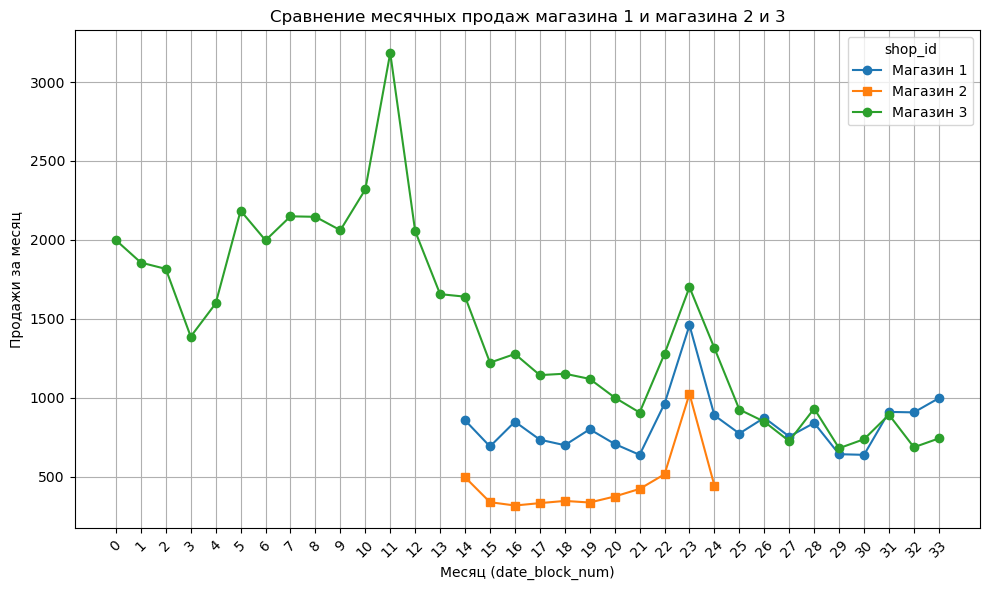

In [51]:
series1 = df_11.groupby('date_block_num')['item_cnt_day'].sum()
series2 = df_22.groupby('date_block_num')['item_cnt_day'].sum()
series3 = df_33.groupby('date_block_num')['item_cnt_day'].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    series1.index, 
    series1.values, 
    marker='o', 
    label='Магазин 1'
)
ax.plot(
    series2.index, 
    series2.values, 
    marker='s', 
    label='Магазин 2'
)
ax.plot(
    series3.index, 
    series3.values, 
    marker='o', 
    label='Магазин 3'
)
ax.set_xlabel('Месяц (date_block_num)')
ax.set_ylabel('Продажи за месяц')
ax.set_title('Сравнение месячных продаж магазина 1 и магазина 2 и 3')
ax.legend(title='shop_id')
ax.grid(True)

plt.xticks(
    sorted(set(series1.index) | set(series2.index) | set(series3.index)),
    rotation=45
)
plt.tight_layout()
plt.show()


In [52]:
df_3 = df_1[df_1['shop_id']==10]
df_3.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
53564,26.01.2013,0,10,6000,190.0,1,RAMAZZOTTI EROS Noi,55,Музыка - CD локального производства,Жуковский ул. Чкалова 39м?
53565,12.01.2013,0,10,6007,180.0,1,RAMMSTEIN Mutter,55,Музыка - CD локального производства,Жуковский ул. Чкалова 39м?
53566,08.01.2013,0,10,6093,200.0,1,"Rayman Origins [PC, Jewel, русская версия]",30,Игры PC - Стандартные издания,Жуковский ул. Чкалова 39м?
53567,12.01.2013,0,10,6093,200.0,1,"Rayman Origins [PC, Jewel, русская версия]",30,Игры PC - Стандартные издания,Жуковский ул. Чкалова 39м?
53568,13.01.2013,0,10,6095,1321.0,1,"Rayman Origins [PS Vita, русская документация]",22,Игры - PSVita,Жуковский ул. Чкалова 39м?


In [53]:
df_4 = df_1[df_1['shop_id']==11]
df_4.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2461045,27.02.2015,25,11,22162,237.11,1,ЯРОСТЬ,40,Кино - DVD,Жуковский ул. Чкалова 39м²
2461046,23.02.2015,25,11,22162,237.11,1,ЯРОСТЬ,40,Кино - DVD,Жуковский ул. Чкалова 39м²
2461047,20.02.2015,25,11,22162,270.00,1,ЯРОСТЬ,40,Кино - DVD,Жуковский ул. Чкалова 39м²
2461048,11.02.2015,25,11,22162,270.00,1,ЯРОСТЬ,40,Кино - DVD,Жуковский ул. Чкалова 39м²
2461049,10.02.2015,25,11,22162,270.00,1,ЯРОСТЬ,40,Кино - DVD,Жуковский ул. Чкалова 39м²


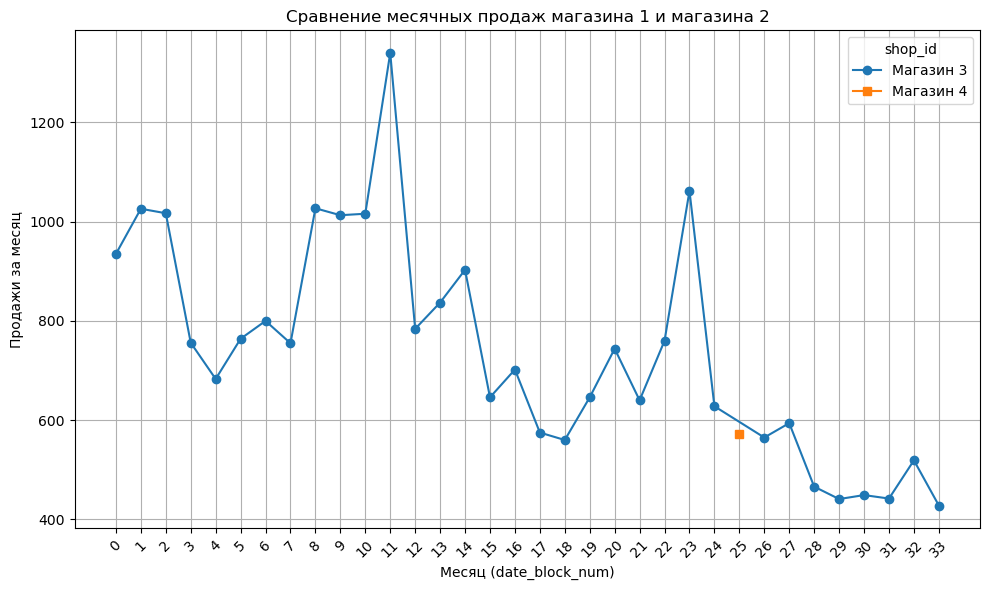

In [54]:
series1 = df_3.groupby('date_block_num')['item_cnt_day'].sum()
series2 = df_4.groupby('date_block_num')['item_cnt_day'].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    series1.index, 
    series1.values, 
    marker='o', 
    label='Магазин 3'
)
ax.plot(
    series2.index, 
    series2.values, 
    marker='s', 
    label='Магазин 4'
)

ax.set_xlabel('Месяц (date_block_num)')
ax.set_ylabel('Продажи за месяц')
ax.set_title('Сравнение месячных продаж магазина 1 и магазина 2')
ax.legend(title='shop_id')
ax.grid(True)

plt.xticks(
    sorted(set(series1.index) | set(series2.index)),
    rotation=45
)
plt.tight_layout()
plt.show()

In [55]:
df_4['date_block_num'].value_counts()

date_block_num
25    499
Name: count, dtype: int64

In [56]:
bam = df_3[df_3['date_block_num']==25]
bam

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name


In [57]:
df_4['item_id'].value_counts

<bound method IndexOpsMixin.value_counts of 2461045    22162
2461046    22162
2461047    22162
2461048    22162
2461049    22162
           ...  
2462003    10389
2462004    10382
2462005    10379
2462006    10298
2462007    10518
Name: item_id, Length: 499, dtype: int64>

Получаем вывод -  получается просто кто-то ошибся и ровно один месяц записал данные одного магазина создав другое название, без зазарения совести добавлю его туда, обьединив эти магазины 

In [58]:
df_1.loc[
    df_1['shop_id'] == 11, 
    ['shop_id', 'shop_name']
] = [10, 'Жуковский ул. Чкалова 39м']


In [59]:
df_5 = df_1[df_1['shop_id']==0]
df_6 = df_1[df_1['shop_id']==57]
print(df_5.head())
print(df_6.head())


             date  date_block_num  shop_id  item_id  item_price  item_cnt_day  \
37589  12.01.2013               0        0    11059        73.0             1   
37590  22.01.2013               0        0    11059        73.0             1   
37591  26.01.2013               0        0    11059        73.0             1   
37592  12.01.2013               0        0    11347       170.0             1   
37593  22.01.2013               0        0    11347       170.0             1   

                                       item_name  item_category_id  \
37589             ДИВЕРСАНТ:КОНЕЦ ВОЙНЫ (регион)                40   
37590             ДИВЕРСАНТ:КОНЕЦ ВОЙНЫ (регион)                40   
37591             ДИВЕРСАНТ:КОНЕЦ ВОЙНЫ (регион)                40   
37592  Дидюля  Grand Collection (mp3-CD) (Jewel)                57   
37593  Дидюля  Grand Collection (mp3-CD) (Jewel)                57   

      item_category_name                      shop_name  
37589         Кино - DVD  !Якутск 

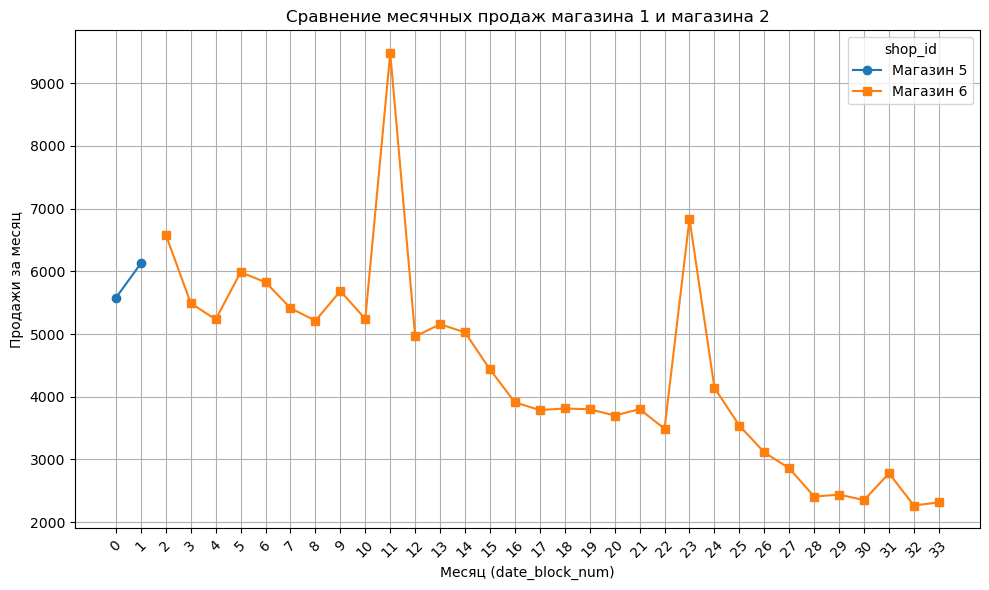

In [60]:
series1 = df_5.groupby('date_block_num')['item_cnt_day'].sum()
series2 = df_6.groupby('date_block_num')['item_cnt_day'].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    series1.index, 
    series1.values, 
    marker='o', 
    label='Магазин 5'
)
ax.plot(
    series2.index, 
    series2.values, 
    marker='s', 
    label='Магазин 6'
)

ax.set_xlabel('Месяц (date_block_num)')
ax.set_ylabel('Продажи за месяц')
ax.set_title('Сравнение месячных продаж магазина 1 и магазина 2')
ax.legend(title='shop_id')
ax.grid(True)

plt.xticks(
    sorted(set(series1.index) | set(series2.index)),
    rotation=45
)
plt.tight_layout()
plt.show()

In [61]:
df_1.loc[
    df_1['shop_id'] == 0, 
    ['shop_id', 'shop_name']
] = [57, 'Якутск Орджоникидзе, 56']


In [62]:
df_month.loc[
    df_month['shop_id'] == 11, 
    ['shop_id']
] = [10]

In [63]:
df_month.loc[
    df_month['shop_id'] == 0, 
    ['shop_id']
] = [57]

In [64]:
pairs = df_month[['item_id', 'shop_id']]
pairs = pairs.drop_duplicates().reset_index(drop=True)

print(pairs.shape)  
pairs.head()


(420738, 2)


,item_id,shop_id
0,30,57
1,31,57
2,32,57
3,33,57
4,35,57


In [65]:
df_int = pairs.merge(
    df_testt,
    on=['item_id', 'shop_id'],
    how='inner'
)

print(df_int.shape)


(111452, 3)


In [66]:
df_testt.shape

(214200, 3)

In [67]:
# поскольку товаров 22170 - чистить 77 пар не вижу смысла
df_items.shape

(22170, 3)

In [68]:

pairs_idx = pd.MultiIndex.from_frame(
    pairs[['item_id', 'shop_id']]
)

test_idx = pd.MultiIndex.from_frame(
    df_testt[['item_id', 'shop_id']].drop_duplicates()
)

common_idx = pairs_idx.intersection(test_idx)

common = pd.DataFrame(
    common_idx.tolist(),
    columns=['item_id', 'shop_id']
)

print(common.shape)   
print(common.head())  


(111452, 2)
   item_id  shop_id
0       30       57
1       31       57
2       32       57
3       33       57
4       42       57


Все супер, мы все убрали и проблем с тем, что нужно предсказать продажи для магазина с id=11  у нас нет, все прекрасно

Теперь будем разбираться с тем, чтобы понять, оригинальные ли у нас названия товаров.

In [69]:
# from scripts.src1 import clean_name
# df_items['name_clean'] = df_items['item_name'].apply(clean_name)



In [70]:
# dups = df_items[df_items['name_clean'].duplicated(keep=False)] \
#            .sort_values('name_clean')
# dups[['item_id', 'item_name', 'name_clean']]


In [71]:
# from itertools import combinations

# groups = dups.groupby('name_clean')['item_id'].unique()

# pairs = []
# for name, ids in groups.items():
#     if len(ids) > 1:
#         for a, b in combinations(ids, 2):
#             pairs.append({'item1_id': a, 'item2_id': b})

# pairs = pd.DataFrame(pairs)


In [72]:
# pairs.head()

In [73]:
# print(len(pairs))


In [ ]:
df_month.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609120 entries, 0 to 1609121
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   item_id           1609120 non-null  int64  
 1   shop_id           1609120 non-null  int64  
 2   item_price        1609120 non-null  float64
 3   date_block_num    1609120 non-null  int64  
 4   item_cnt_month    1609120 non-null  int64  
 5   item_category_id  1609120 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 85.9 MB


In [ ]:
df_month = df_month.sort_values(['item_id','shop_id','date_block_num'])

for lag in [1, 3, 6, 12]:
    df_month[f'cnt_lag_{lag}'] = (
        df_month
        .groupby(['item_id','shop_id'])['item_cnt_month']
        .shift(lag)
        .fillna(0)
        .astype(int)
    )


In [ ]:
df_month.head()

,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id,cnt_lag_1,cnt_lag_3,cnt_lag_6,cnt_lag_12
1358995,0,54,58.0,20,1,40,0,0,0,0
1429466,1,55,4490.0,15,2,76,0,0,0,0
1429467,1,55,4490.0,18,1,76,2,0,0,0
1429468,1,55,4490.0,19,1,76,1,0,0,0
1429469,1,55,4490.0,20,1,76,1,2,0,0


In [ ]:
def add_rolling_means(df, windows=[3, 6, 12]):
    for w in windows:
        df[f'cnt_rm_{w}'] = (
            df
            .groupby(['item_id', 'shop_id'])['item_cnt_month']
            .shift(1)                             
            .rolling(window=w, min_periods=1)    
            .mean()                               
            .fillna(0)                           
        )
    return df

df_month = add_rolling_means(df_month)
df_month.head()


,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id,cnt_lag_1,cnt_lag_3,cnt_lag_6,cnt_lag_12,cnt_rm_3,cnt_rm_6,cnt_rm_12
1358995,0,54,58.0,20,1,40,0,0,0,0,0.000000,0.000000,0.000000
1429466,1,55,4490.0,15,2,76,0,0,0,0,0.000000,0.000000,0.000000
1429467,1,55,4490.0,18,1,76,2,0,0,0,2.000000,2.000000,2.000000
1429468,1,55,4490.0,19,1,76,1,0,0,0,1.500000,1.500000,1.500000
1429469,1,55,4490.0,20,1,76,1,2,0,0,1.333333,1.333333,1.333333


In [ ]:

df_month['item_avg_price'] = (
    df_month
      .groupby('item_id')['item_price']
      .transform('mean')
)


df_month['cat_avg_price'] = (
    df_month
      .groupby('item_category_id')['item_price']
      .transform('mean')
)


df_month.head()


,item_id,shop_id,item_price,date_block_num,item_cnt_month,item_category_id,cnt_lag_1,cnt_lag_3,cnt_lag_6,cnt_lag_12,cnt_rm_3,cnt_rm_6,cnt_rm_12,item_avg_price,cat_avg_price
1358995,0,54,58.0,20,1,40,0,0,0,0,0.000000,0.000000,0.000000,58.0,223.447056
1429466,1,55,4490.0,15,2,76,0,0,0,0,0.000000,0.000000,0.000000,4490.0,1858.153342
1429467,1,55,4490.0,18,1,76,2,0,0,0,2.000000,2.000000,2.000000,4490.0,1858.153342
1429468,1,55,4490.0,19,1,76,1,0,0,0,1.500000,1.500000,1.500000,4490.0,1858.153342
1429469,1,55,4490.0,20,1,76,1,2,0,0,1.333333,1.333333,1.333333,4490.0,1858.153342


In [ ]:
df_2.head()

,ID,shop_id,item_id,item_name,item_category_id,item_category_name,shop_name
0,0,5,5037,"NHL 15 [PS3, русские субтитры]",19,Игры - PS3,"Вологда ТРЦ ""Мармелад"""
1,1,5,5320,ONE DIRECTION Made In The A.M.,55,Музыка - CD локального производства,"Вологда ТРЦ ""Мармелад"""
2,2,5,5233,"Need for Speed Rivals (Essentials) [PS3, русск...",19,Игры - PS3,"Вологда ТРЦ ""Мармелад"""
3,3,5,5232,"Need for Speed Rivals (Classics) [Xbox 360, ру...",23,Игры - XBOX 360,"Вологда ТРЦ ""Мармелад"""
4,4,5,5268,"Need for Speed [PS4, русская версия]",20,Игры - PS4,"Вологда ТРЦ ""Мармелад"""


In [ ]:
df_month_test = df_2[['shop_id', 'item_id','item_category_id' ]]
df_month_test.head()

,shop_id,item_id,item_category_id
0,5,5037,19
1,5,5320,55
2,5,5233,19
3,5,5232,23
4,5,5268,20


In [ ]:
df_month_test['date_block_num'] = 34
df_month_test.head()

C:\Users\Barys\AppData\Local\Temp\ipykernel_12412\4207175823.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_month_test['date_block_num'] = 34


,shop_id,item_id,item_category_id,date_block_num
0,5,5037,19,34
1,5,5320,55,34
2,5,5233,19,34
3,5,5232,23,34
4,5,5268,20,34


In [ ]:
item_avg = (
    df_month
      .groupby('item_id')['item_price']
      .mean()
      .reset_index(name='item_avg_price')
)


cat_avg = (
    df_month
      .groupby('item_category_id')['item_price']
      .mean()
      .reset_index(name='cat_avg_price')
)

df_month_test = (
    df_month_test
      .merge(item_avg, on='item_id', how='left')
      .merge(cat_avg,  on='item_category_id', how='left')
)


In [ ]:
print(df_month_test.isna().sum())

shop_id                 0
item_id                 0
item_category_id        0
date_block_num          0
item_avg_price      15246
cat_avg_price           0
dtype: int64


In [ ]:
df_month_test['item_avg_price'] = (
    df_month_test['item_avg_price']
    .fillna(df_month_test['cat_avg_price'])
)

In [ ]:
df_month_test.isna().sum()

shop_id             0
item_id             0
item_category_id    0
date_block_num      0
item_avg_price      0
cat_avg_price       0
dtype: int64

In [ ]:
df_month_test.head()

,shop_id,item_id,item_category_id,date_block_num,item_avg_price,cat_avg_price
0,5,5037,19,34,1983.279159,1425.059291
1,5,5320,55,34,281.810675,281.810675
2,5,5233,19,34,863.698640,1425.059291
3,5,5232,23,34,792.242500,1456.316252
4,5,5268,20,34,2711.051554,2711.051554


In [ ]:
df_buf=df_month[['shop_id','item_id','item_category_id','date_block_num','item_cnt_month', 'item_avg_price','cat_avg_price']]

df_test = df_month_test.copy()
df_test['item_cnt_month'] = np.nan

full = pd.concat([df_buf, df_test], ignore_index=True)

full.sort_values(['item_id','shop_id','date_block_num'], inplace=True)

for lag in [1,3,6,12]:
    full[f'cnt_lag_{lag}'] = (
        full
        .groupby(['item_id','shop_id'])['item_cnt_month']
        .shift(lag)
        .fillna(0)
    )

for w in [3, 6, 12]:
    full[f'cnt_rm_{w}'] = (
        full
          .groupby(['item_id','shop_id'])['item_cnt_month']
          .transform(lambda x, window=w: 
              x.shift(1)
               .rolling(window=window, min_periods=1)
               .mean()
          )
          .fillna(0)
    )



df_test_final = (
    full[full['date_block_num']==34]
    .drop(columns=['item_cnt_month'])
    .reset_index(drop=True)
)

df_test_final.head()

,shop_id,item_id,item_category_id,date_block_num,item_avg_price,cat_avg_price,cnt_lag_1,cnt_lag_3,cnt_lag_6,cnt_lag_12,cnt_rm_3,cnt_rm_6,cnt_rm_12
0,2,30,40,34,262.081535,223.447056,1.0,1.0,0.0,0.0,1.000000,1.000000,1.000000
1,3,30,40,34,262.081535,223.447056,1.0,2.0,1.0,0.0,1.333333,1.166667,2.000000
2,4,30,40,34,262.081535,223.447056,1.0,7.0,0.0,0.0,3.666667,3.666667,3.666667
3,5,30,40,34,262.081535,223.447056,1.0,1.0,1.0,0.0,1.000000,1.000000,2.111111
4,6,30,40,34,262.081535,223.447056,1.0,1.0,1.0,20.0,1.000000,1.000000,3.583333


In [ ]:
cols=['shop_id','item_id','item_category_id','date_block_num','item_cnt_month', 'item_avg_price','cat_avg_price','cnt_lag_1','cnt_lag_3','cnt_lag_6','cnt_lag_12', 'cnt_rm_3','cnt_rm_6','cnt_rm_12']
df_train_final = df_month[cols]
df_train_final.head()

,shop_id,item_id,item_category_id,date_block_num,item_cnt_month,item_avg_price,cat_avg_price,cnt_lag_1,cnt_lag_3,cnt_lag_6,cnt_lag_12,cnt_rm_3,cnt_rm_6,cnt_rm_12
1358995,54,0,40,20,1,58.0,223.447056,0,0,0,0,0.000000,0.000000,0.000000
1429466,55,1,76,15,2,4490.0,1858.153342,0,0,0,0,0.000000,0.000000,0.000000
1429467,55,1,76,18,1,4490.0,1858.153342,2,0,0,0,2.000000,2.000000,2.000000
1429468,55,1,76,19,1,4490.0,1858.153342,1,0,0,0,1.500000,1.500000,1.500000
1429469,55,1,76,20,1,4490.0,1858.153342,1,2,0,0,1.333333,1.333333,1.333333


In [ ]:
df_test_final = df_test_final.merge(
    df_testt[['shop_id', 'item_id', 'ID']],
    on=['shop_id', 'item_id'],
    how='left'
)
df_test_final.head()

,shop_id,item_id,item_category_id,date_block_num,item_avg_price,cat_avg_price,cnt_lag_1,cnt_lag_3,cnt_lag_6,cnt_lag_12,cnt_rm_3,cnt_rm_6,cnt_rm_12,ID
0,2,30,40,34,262.081535,223.447056,1.0,1.0,0.0,0.0,1.000000,1.000000,1.000000,22987
1,3,30,40,34,262.081535,223.447056,1.0,2.0,1.0,0.0,1.333333,1.166667,2.000000,17887
2,4,30,40,34,262.081535,223.447056,1.0,7.0,0.0,0.0,3.666667,3.666667,3.666667,7687
3,5,30,40,34,262.081535,223.447056,1.0,1.0,1.0,0.0,1.000000,1.000000,2.111111,2587
4,6,30,40,34,262.081535,223.447056,1.0,1.0,1.0,20.0,1.000000,1.000000,3.583333,12787


In [ ]:
#df_train_final.to_csv('df_train_final.csv', index=False)


In [ ]:
#df_test_final.to_csv('df_test_final.csv', index=False)


# EDA

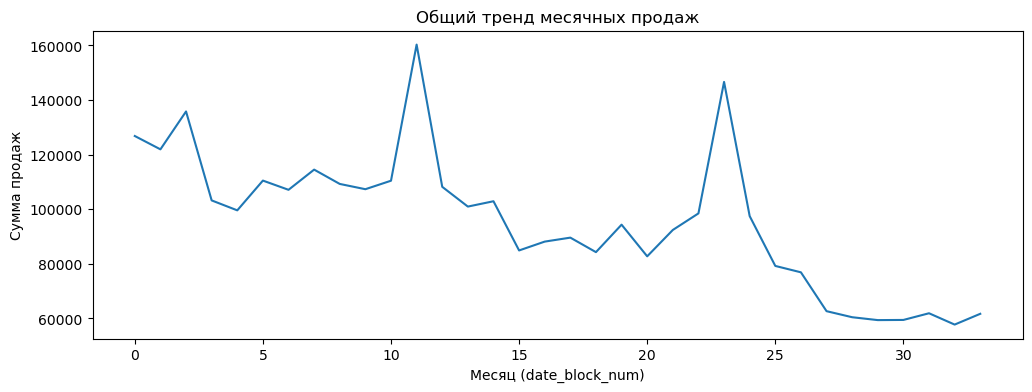

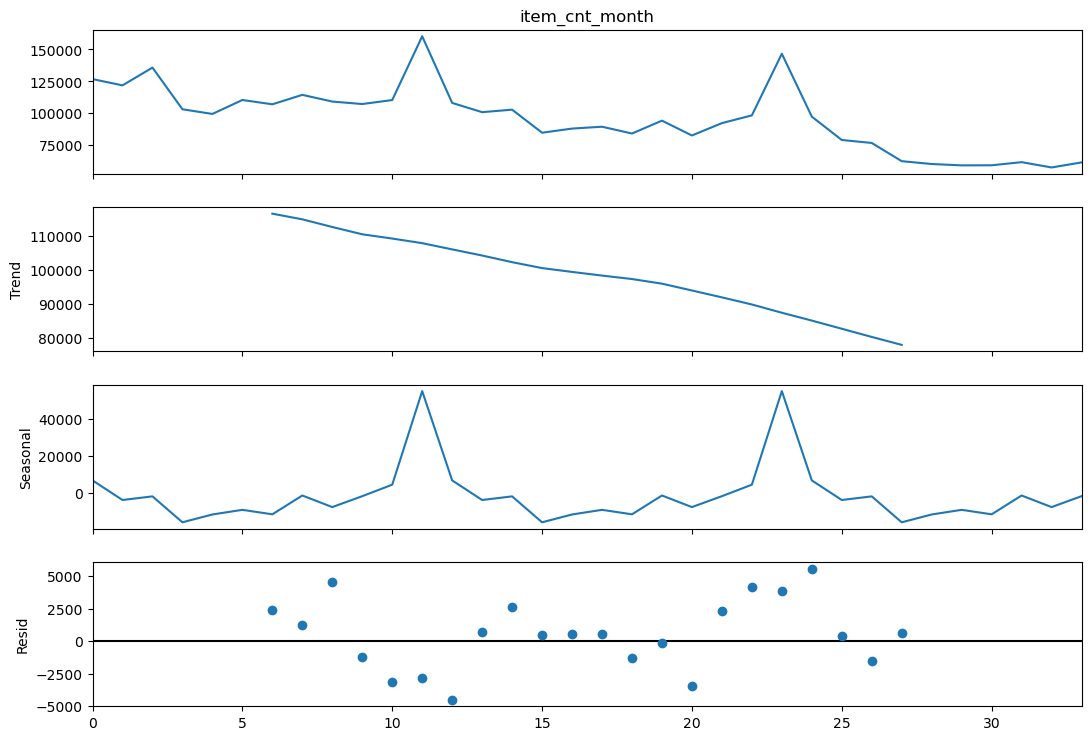

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly = (
    df_train_final
    .groupby('date_block_num', as_index=False)['item_cnt_month']
    .sum()
)
# просто хотим прочекать вообще продажу всех товаров за каждый месяц
plt.figure(figsize=(12,4))
sns.lineplot(
    data=monthly,
    x='date_block_num',
    y='item_cnt_month'
)
#
plt.title('Общий тренд месячных продаж')
plt.xlabel('Месяц (date_block_num)')
plt.ylabel('Сумма продаж')
plt.show()

monthly_ts = monthly.set_index('date_block_num')['item_cnt_month']
decomp = seasonal_decompose(monthly_ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()

C:\Users\Barys\AppData\Local\Temp\ipykernel_12412\4187565210.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


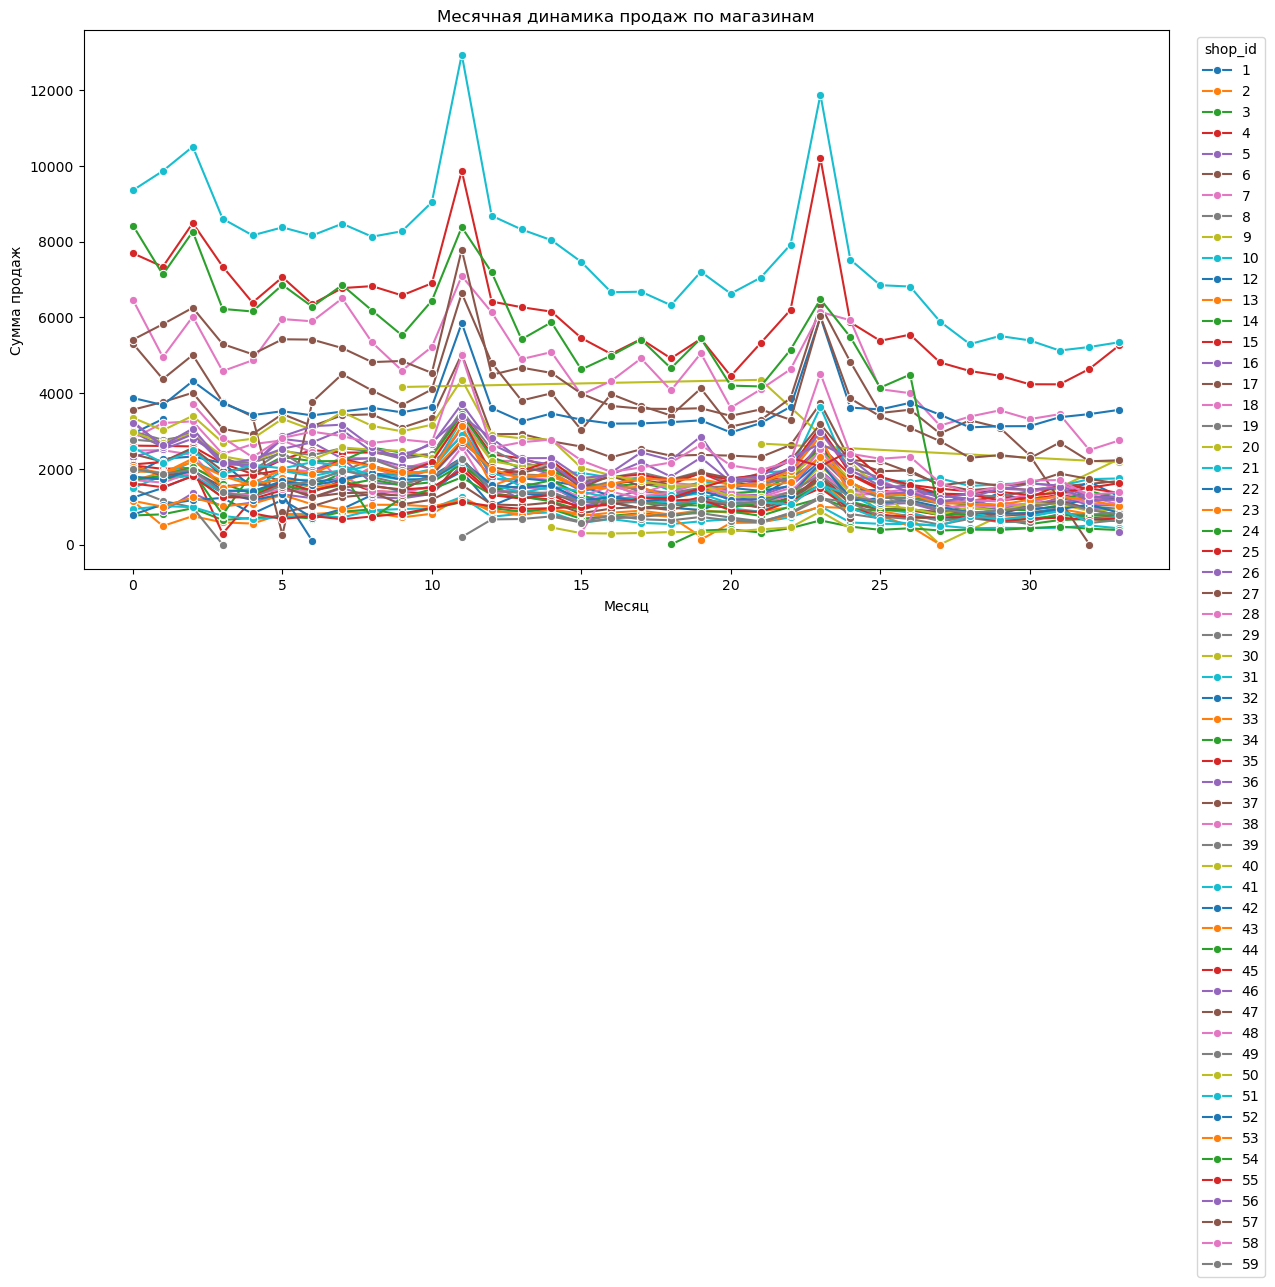

In [ ]:
df_plot = (
    df_month
      .groupby(['date_block_num', 'shop_id'])['item_cnt_month']
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_plot,
    x='date_block_num',
    y='item_cnt_month',
    hue='shop_id',
    palette='tab10',
    marker='o'
)
plt.xlabel('Месяц')
plt.ylabel('Сумма продаж')
plt.title('Месячная динамика продаж по магазинам')
plt.legend(title='shop_id', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


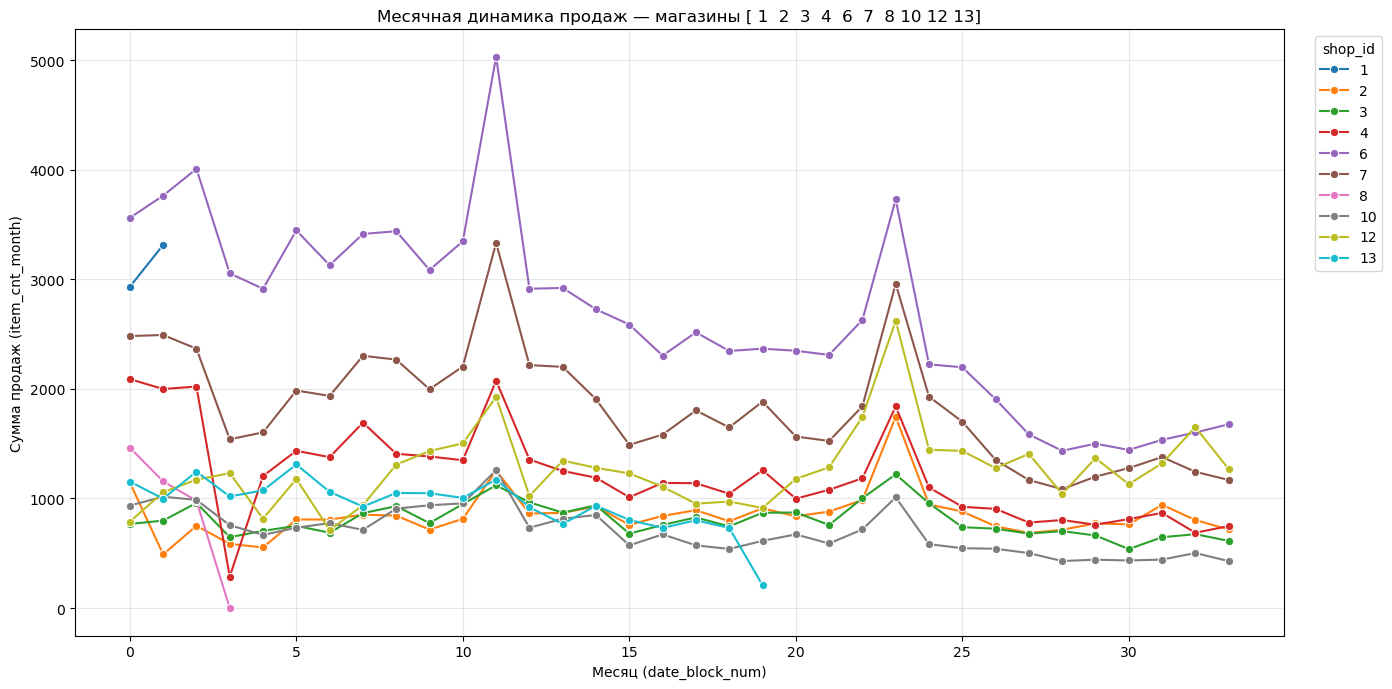

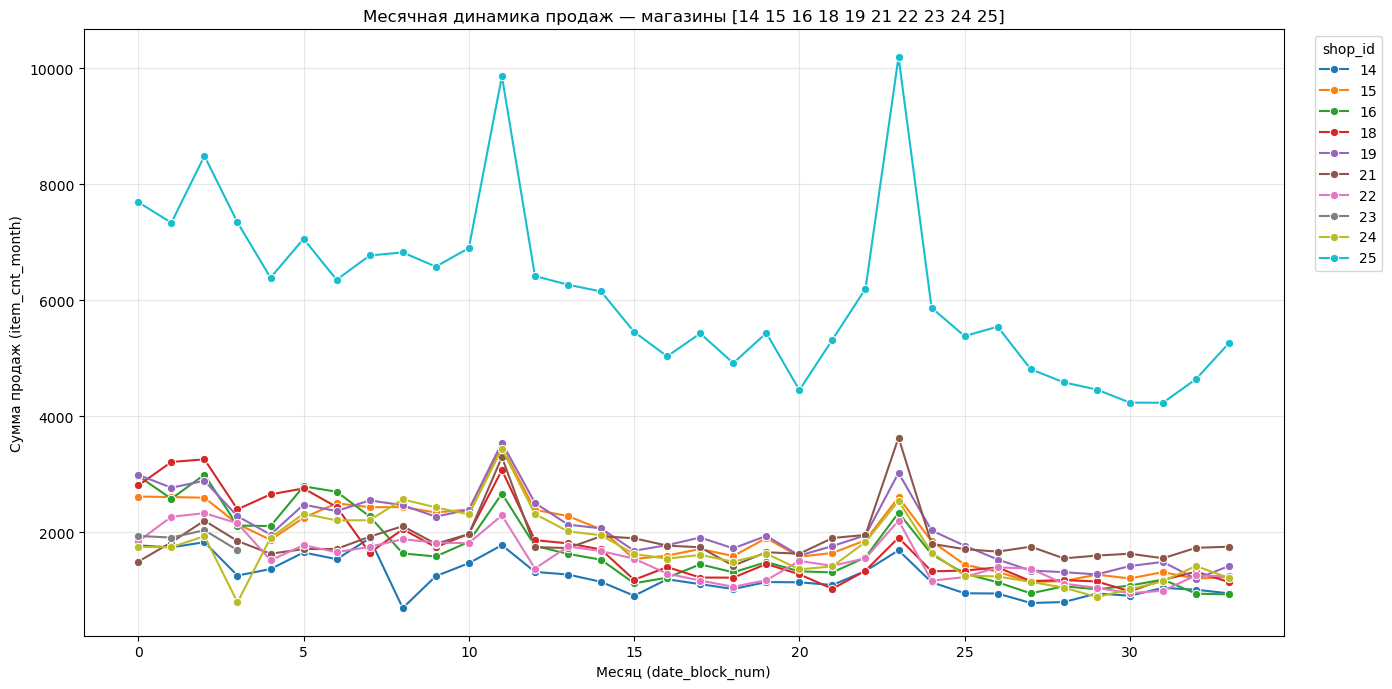

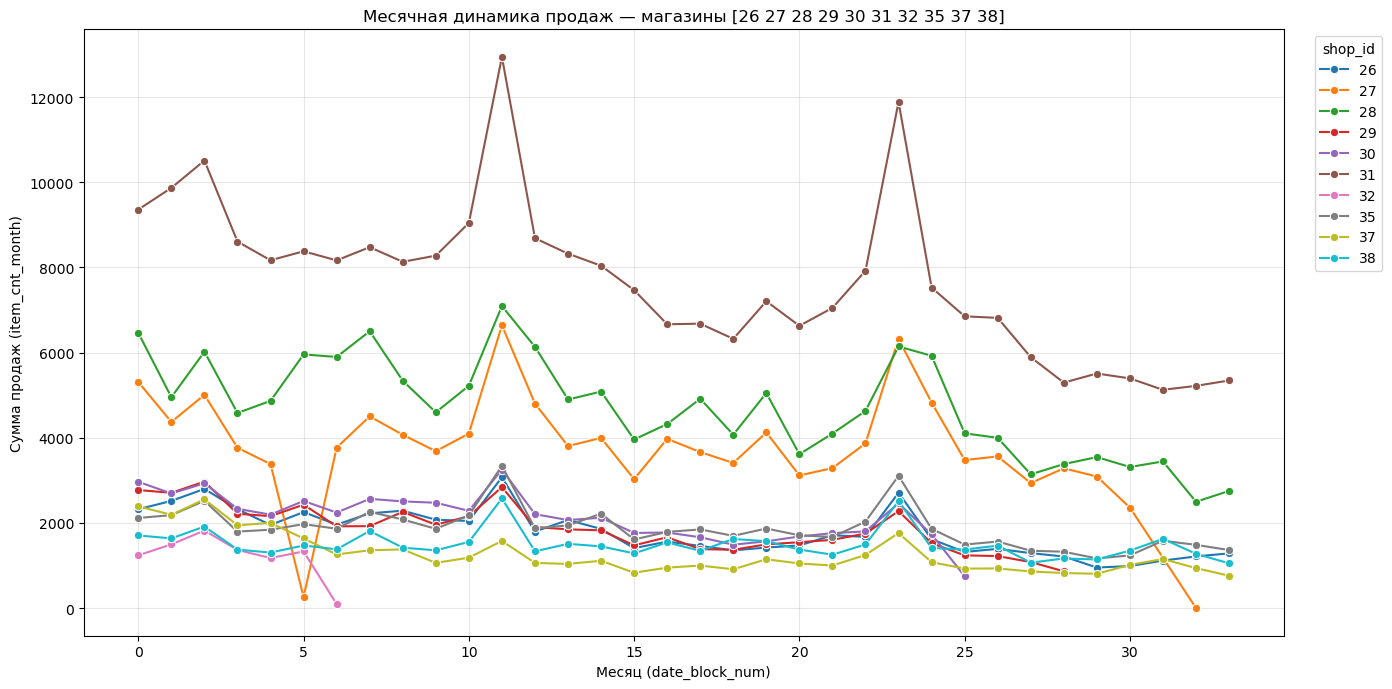

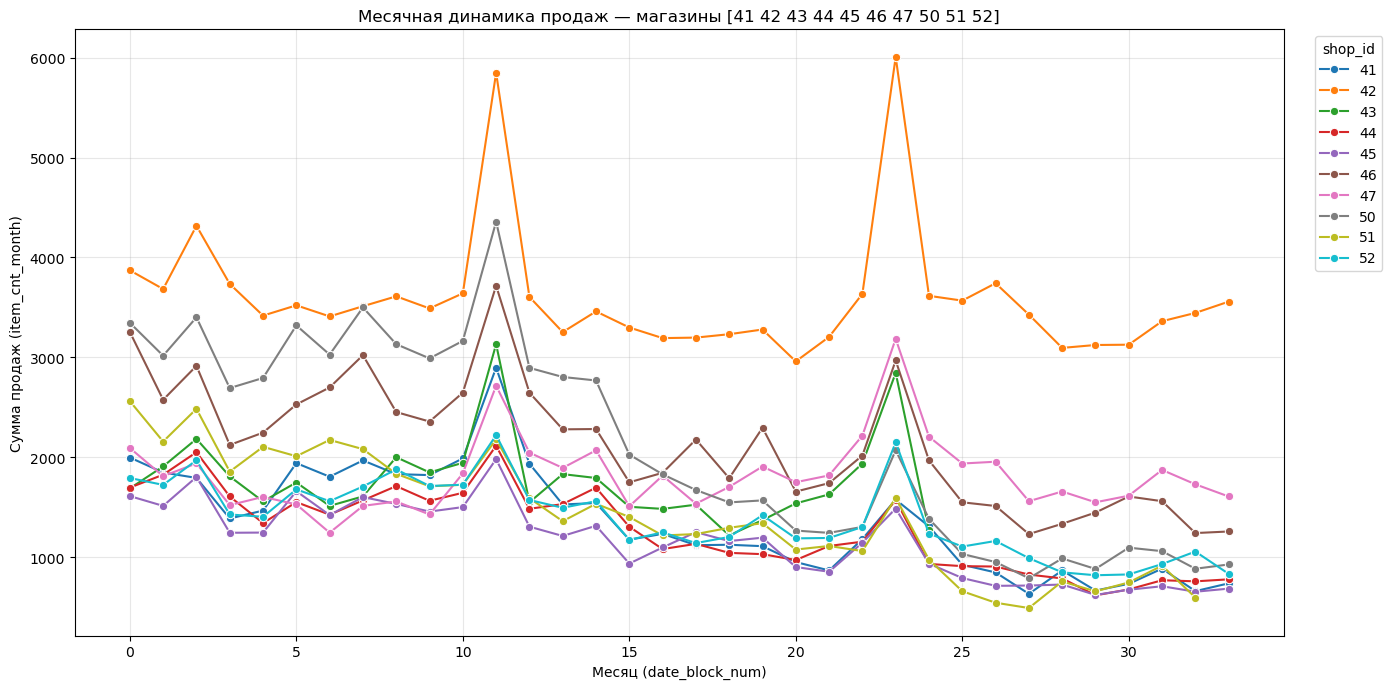

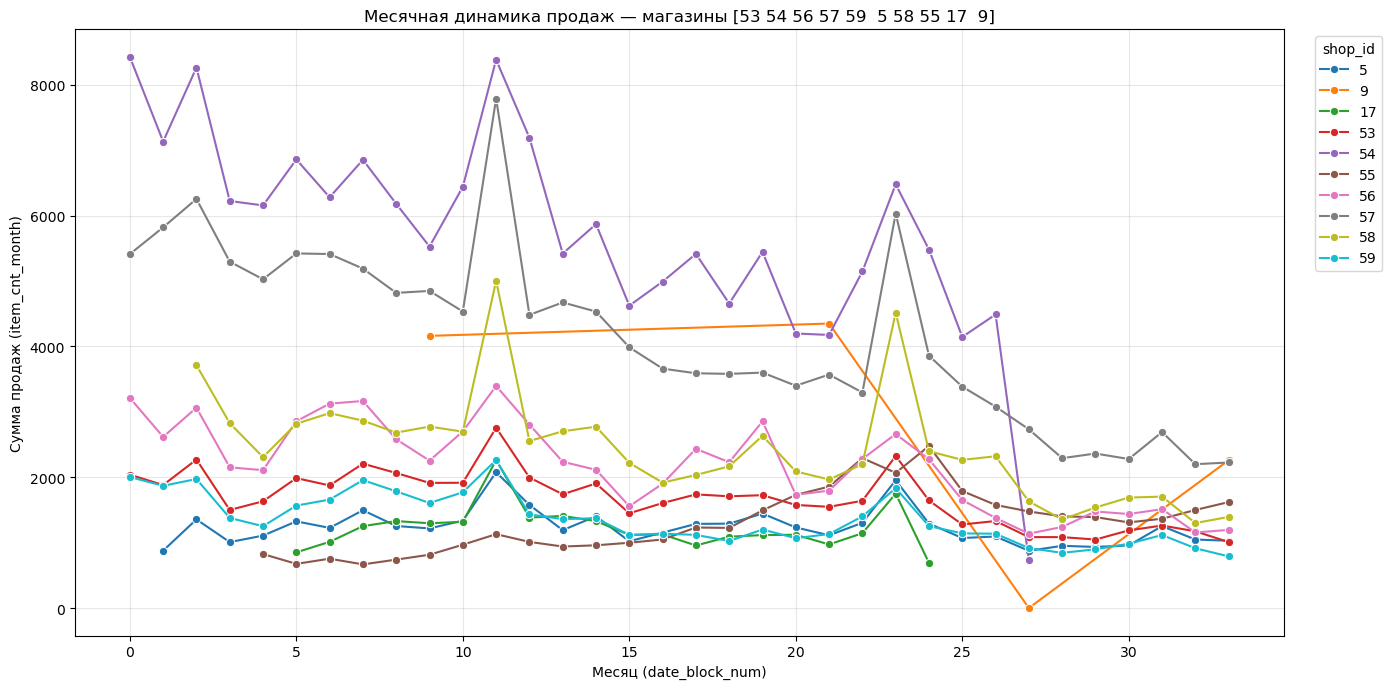

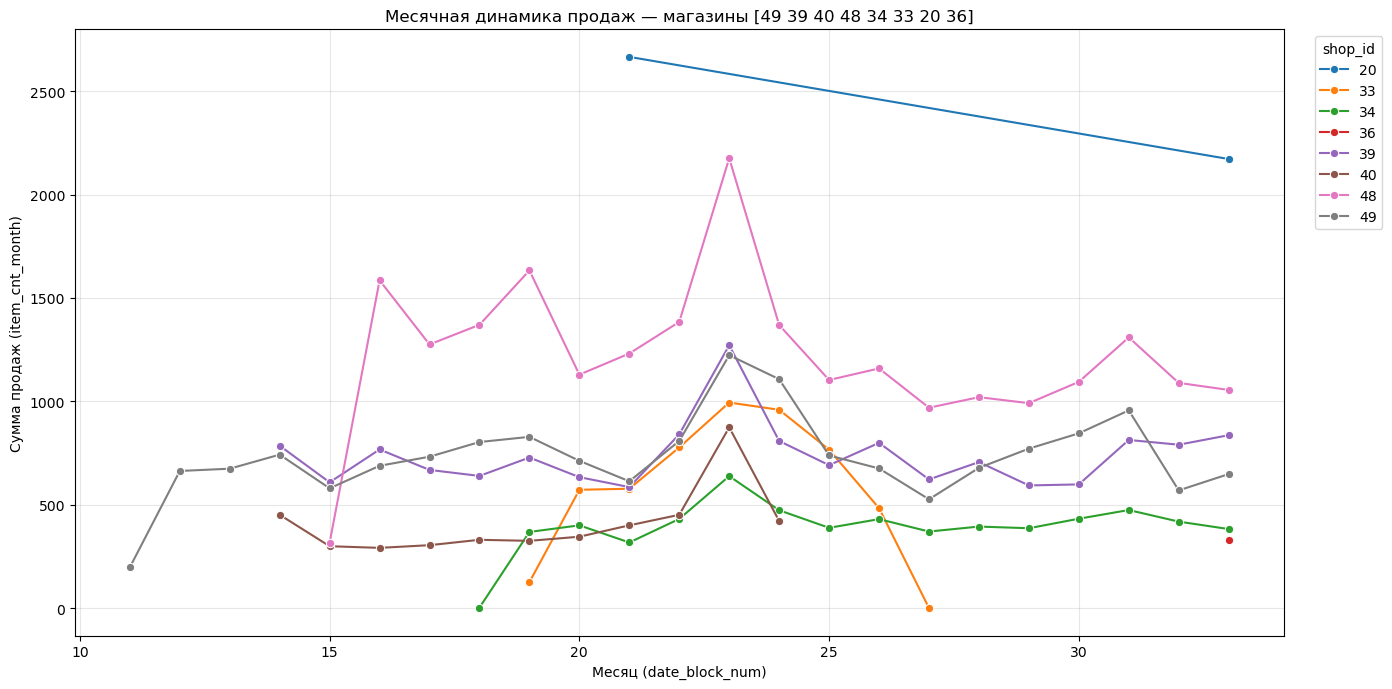

In [ ]:


df_plot = (
    df_train_final
      .groupby(['date_block_num', 'shop_id'])['item_cnt_month']
      .sum()
      .reset_index()
)

all_shops = df_plot['shop_id'].unique()

def chunk_list(lst, n):
    
    return [lst[i:i + n] for i in range(0, len(lst), n)]

shop_chunks = chunk_list(all_shops, 10)

for chunk in shop_chunks:
    df_chunk = df_plot[df_plot['shop_id'].isin(chunk)]
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=df_chunk,
        x='date_block_num',
        y='item_cnt_month',
        hue='shop_id',
        palette=sns.color_palette('tab10', n_colors=len(chunk)),
        marker='o'
    )
    
    plt.xlabel('Месяц (date_block_num)')
    plt.ylabel('Сумма продаж (item_cnt_month)')
    plt.title(f'Месячная динамика продаж — магазины {chunk}')
    plt.legend(title='shop_id', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


C:\Users\Barys\AppData\Local\Temp\ipykernel_12412\3097035218.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


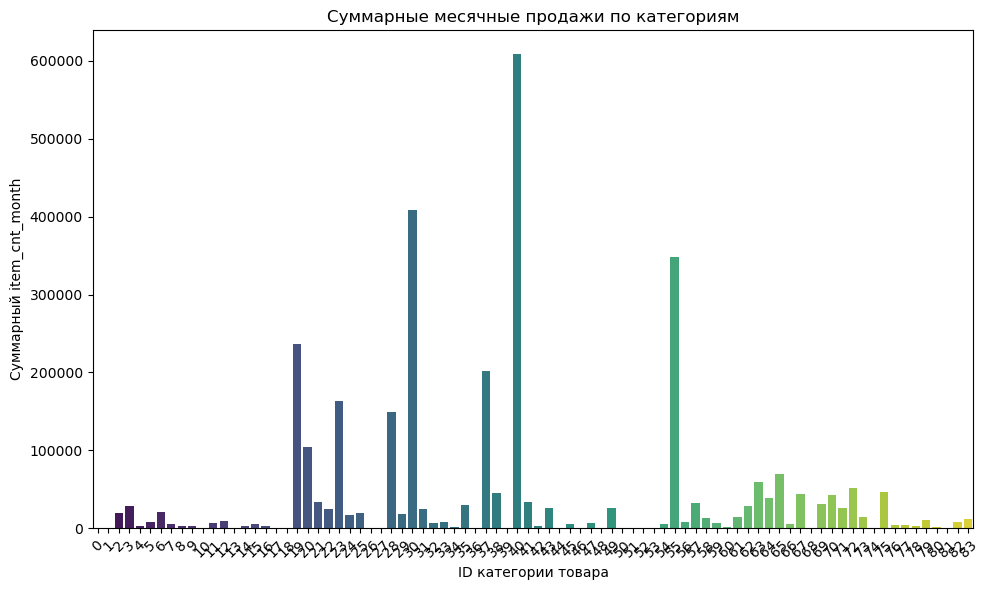

In [ ]:
category_sales = (
    df_train_final
      .groupby('item_category_id')['item_cnt_month']
      .sum()
      .reset_index()
      .sort_values('item_cnt_month', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_sales,
    x='item_category_id',
    y='item_cnt_month',
    palette='viridis'
)
plt.title('Суммарные месячные продажи по категориям')
plt.xlabel('ID категории товара')
plt.ylabel('Суммарный item_cnt_month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df_train_final.head()

,shop_id,item_id,item_category_id,date_block_num,item_cnt_month,item_avg_price,cat_avg_price,cnt_lag_1,cnt_lag_3,cnt_lag_6,cnt_lag_12,cnt_rm_3,cnt_rm_6,cnt_rm_12
1358995,54,0,40,20,1,58.0,223.447056,0,0,0,0,0.000000,0.000000,0.000000
1429466,55,1,76,15,2,4490.0,1858.153342,0,0,0,0,0.000000,0.000000,0.000000
1429467,55,1,76,18,1,4490.0,1858.153342,2,0,0,0,2.000000,2.000000,2.000000
1429468,55,1,76,19,1,4490.0,1858.153342,1,0,0,0,1.500000,1.500000,1.500000
1429469,55,1,76,20,1,4490.0,1858.153342,1,2,0,0,1.333333,1.333333,1.333333


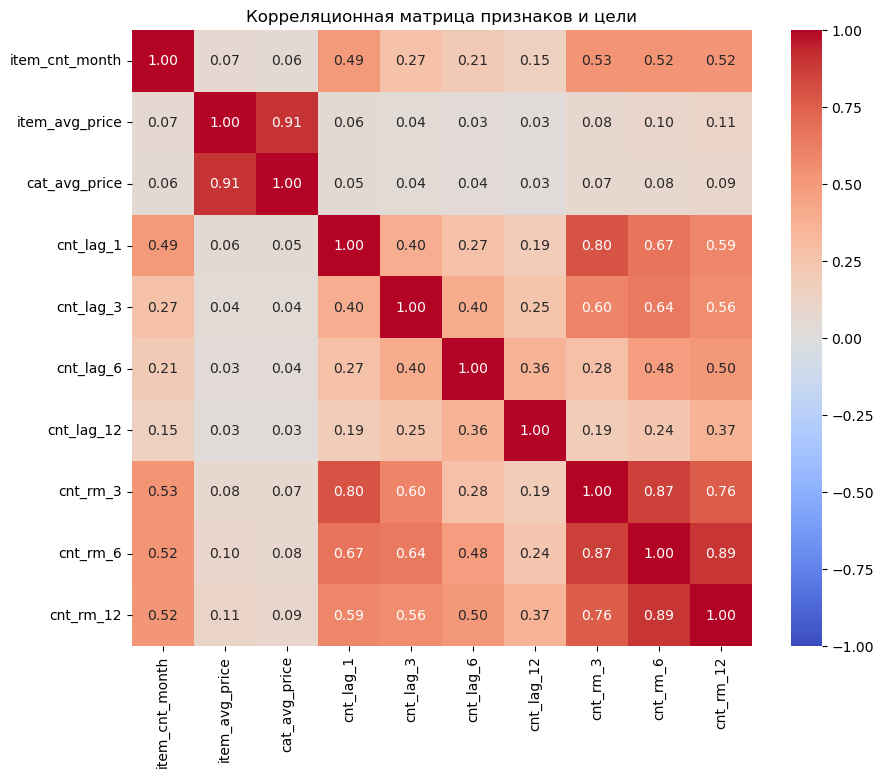

In [ ]:
# возьму только числовые для корреляционной матрицы 
cols = [
    'item_cnt_month',
    'item_avg_price', 'cat_avg_price',
    'cnt_lag_1',  'cnt_lag_3',
    'cnt_lag_6', 'cnt_lag_12',
    'cnt_rm_3', 'cnt_rm_6', 'cnt_rm_12'
]

corr = df_train_final[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",   
    vmin=-1, vmax=1
)
plt.title("Корреляционная матрица признаков и цели")
plt.show()


### Modelling

In [ ]:
from Splitter import Splitter

splitter = Splitter(time_col = 'date_block_num', train_end = 33)

In [ ]:
from Validator import Validator
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from math import sqrt
 
validator = Validator(df_train_final, splitter, model = Ridge( alpha = 1.0), metric   = lambda y, yhat: sqrt(mean_squared_error(y, yhat)))
features =['item_avg_price','cat_avg_price','cnt_lag_1','cnt_lag_3','cnt_lag_6','cnt_lag_12', 'cnt_rm_3','cnt_rm_6','cnt_rm_12']
result = validator.run(features, target_col = 'item_cnt_month')

print('Val RMSE:', result)

Val RMSE: {'val_score': 2.461437968849961, 'pred_val': array([1.44209478, 1.45061218, 1.33254965, ..., 2.83567798, 1.47717182,
       1.31954221], shape=(31531,))}


In [ ]:
X_tr, y_tr, X_val, y_val = splitter.split(
    df_train_final,
    features,            
    target_col="item_cnt_month"
)
X_full = pd.concat([X_tr, X_val], axis=0)
y_full = pd.concat([y_tr, y_val], axis=0)

final_model = Ridge(alpha=1.0, random_state=42)
final_model.fit(X_full, y_full)


X_test = df_test_final[features]


test_pred = final_model.predict(X_test)


submission = pd.DataFrame({
    "ID":              df_test_final["ID"],
    "item_cnt_month":  test_pred
})

submission.to_csv("submission.csv", index=False)